# 소득과 입지, 주거 구조로 캘리포니아 주택가격을 예측할 수 있는가

**작성자:** bolly0809-coder &nbsp;&nbsp;|&nbsp;&nbsp; **작성일:** 2026-09-02

[프로젝트 요약·핵심 결과·참고자료·회고](../README.md)

## 05. 최종모델 평가와 SHAP 분석

> 최종 CatBoost 모델의 일반화 성능과 과적합 여부를 점검하고 예측에 중요한 요인을 해석합니다.

| 구분 | 내용 |
|---|---|
| 분석 대상 | 1990년 미국 인구조사 기반 California Housing 데이터 |
| 종속변수 | `median_house_value` — 지역별 주택 중위가격 |
| 입력 | 튜닝된 CatBoost 모델과 검증 데이터 |
| 핵심 작업 | 과적합 진단, Feature Importance, 변수 축소 재학습, SHAP |
| 산출물 | 최종 성능표와 변수 영향 해석 |

**노트북 이동:** [01](01_프로젝트_개요와_데이터_품질.ipynb) · [02](02_탐색적_데이터_분석.ipynb) · [03](03_분석용_데이터_전처리.ipynb) · [04](04_회귀모델링과_하이퍼파라미터_튜닝.ipynb) · [05](05_최종모델_평가와_SHAP.ipynb)

---

## #01. 준비작업

### 1. 라이브러리 참조


In [1]:
from jussam import load_data
from helpers import *
from sklearn.base import clone
import glob as gl
from sklearn.model_selection import train_test_split
# 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


In [2]:
# 선형 계열 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# 비선형 계열 모델
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# 트리계열 모델
from sklearn.tree import DecisionTreeRegressor

# 앙상블 모델
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

### 2. 데이터 불러오기 + 타입 체크

In [3]:
# 분석용 데이터 전처리가 완료된 데이터 셋
origin = load_data("california_housing_feature_log_labelled")
df = my_qtcheck.set_type(origin, as_category=["is_age_capped", "is_income_capped", "ocean_area", "special_cluster"])

📚 캘리포니아 주택 가격 데이터셋의 파생변수 추가 버전에 대한 로그 변환 및 라벨링 처리 데이터 (출처: 자체 작업)

    field                     description
--  ------------------------  -------------------------------------------------
 0  housing_median_age        주택 중위 연령 (로그변환됨)
 1  rooms_per_person          인당 방 수 (로그변환됨)
 2  rooms_per_household       가구당 방 수 (로그변환됨)
 3  bedrooms_per_room         방당 침실 수 (로그변환됨)
 4  population_per_household  가구당 인구 (로그변환됨)
 5  income_per_person         인당 소득 (로그변환됨)
 6  is_age_capped             주택 연령 제한 여부(범주형: 제한안함=0, 제한함=1)
 7  is_income_capped          소득 제한 여부(범주형: 제한안함=0, 제한함=1)
 8  ocean_area                해양 지역 여부(범주형: COASTAL=0, INLAND=1)
 9  special_cluster           공간정보 클러스터 여부(범주형 0~4)
10  median_house_value        주택 중위 가격(종속변수, 로그변환됨)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   housing_median_age   

### 3. 데이터 분할

In [4]:
# 독립변수 분리
feature = df.drop(columns=["median_house_value"])

# 종속변수 분리
target = df["median_house_value"]

# 훈련, 검증 데이터 분할
x_train, x_test, y_train, y_test = train_test_split(
        feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((16346, 10), (4087, 10), (16346,), (4087,))

### 4. 저장폴더 지정

In [5]:
# 04번 노트북에서 생성된 튜닝 폴더 중 가장 최근 폴더를 사용한다.
tuned_dirs = sorted(gl.glob("ml_models/*_tuned"))
if not tuned_dirs:
    raise FileNotFoundError("먼저 04번 노트북을 실행해 튜닝 모델을 저장하세요.")

workdir = tuned_dirs[-1]
workdir


'ml_models\\20260902_114312_tuned'

In [6]:
# 새로운 학습 결과를 저장할 폴더 위치
savedir = workdir.replace("tuned", "importance")
savedir

'ml_models\\20260902_114312_importance'

## #02. 상위 성능 모델에 대한 과적합 판정

### 1. CatBoost 

- 모델 학습시 설정한 범주형 변수 지정이 필요하다.

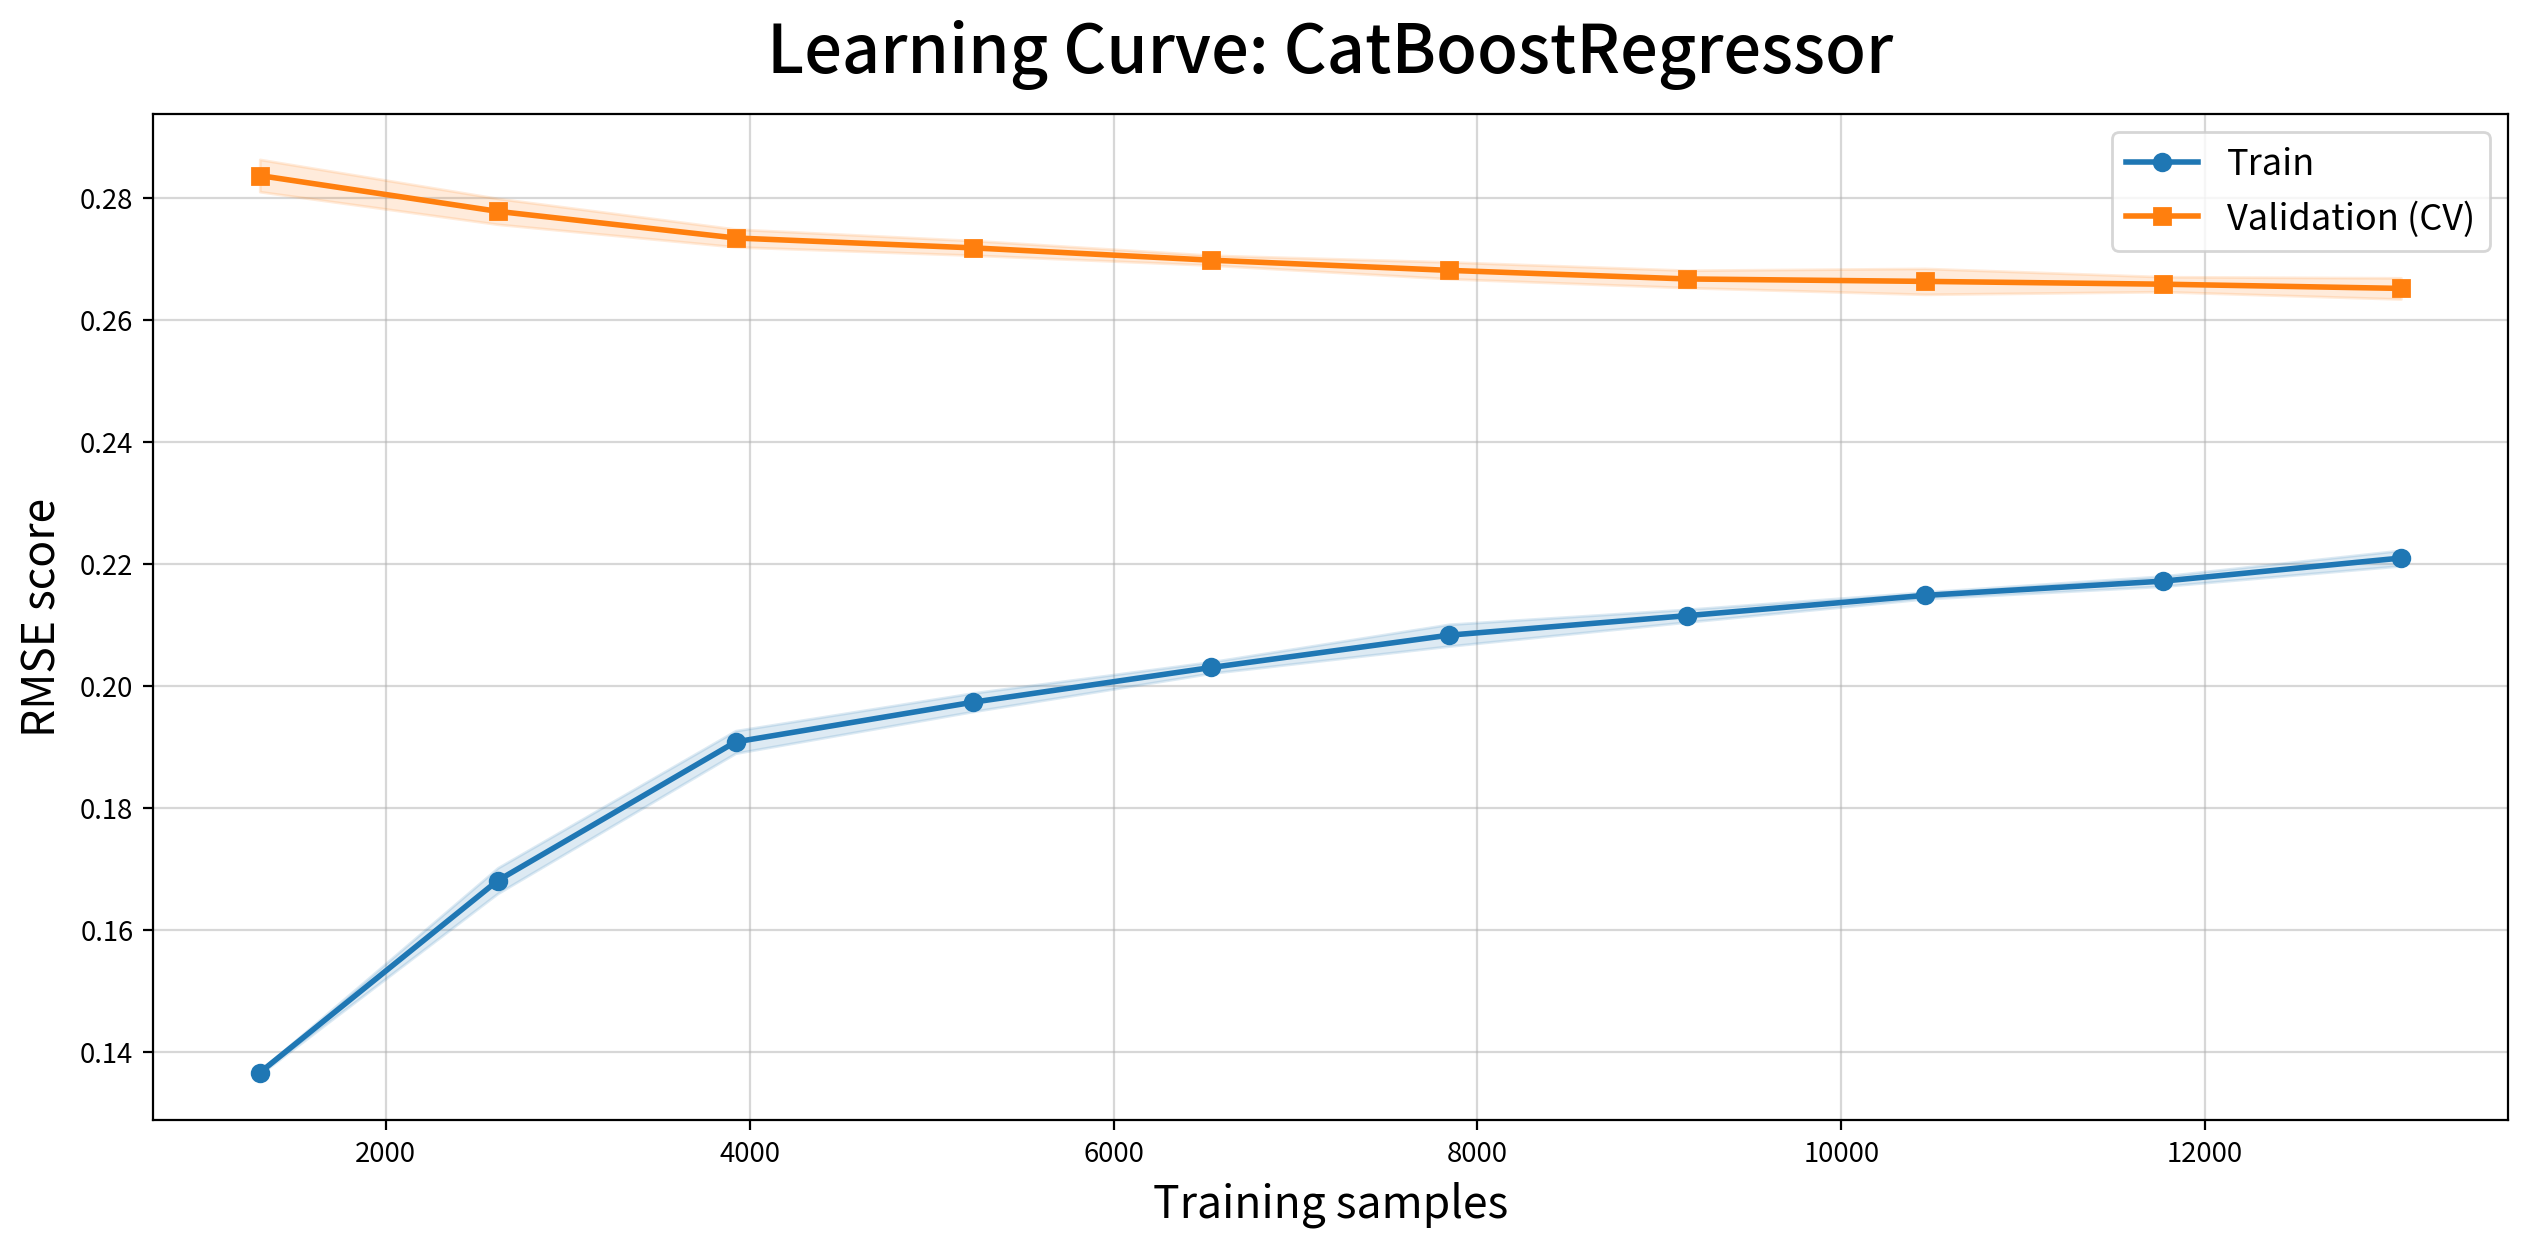


◆ Fit Diagnosis: CatBoostRegressor  (threshold=15%, 기준=Train↔CV 5-Fold)
   ▷ 탐색 객체의 best_params: {'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.03}
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
   - RMSE    Train=     0.2246  CV=     0.2653 (±0.0016)  Test=     0.2660  Gap%=   15.36%  [과대적합] ⚠

   ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) — 훈련↔CV 격차가 큼
     · train R2=0.8438 (과소적합 기준 < 0.3) · CV R2=0.7818

CPU times: total: 3.59 s
Wall time: 10min 27s


,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.225,0.265,0.002,0.266,0.041,15.360,과대적합


In [7]:
%%time
model = my_ml.load_model(f"{workdir}/catboost.pkl")
my_ml.reg_overfit(model, x_train, y_train, x_test, y_test, metrics='RMSE', fit_params={'model__cat_features': my_qtcheck.get_categorical_column_names(x_train)})

## #03. Feature Importance

### 1. Feature Importance 도출

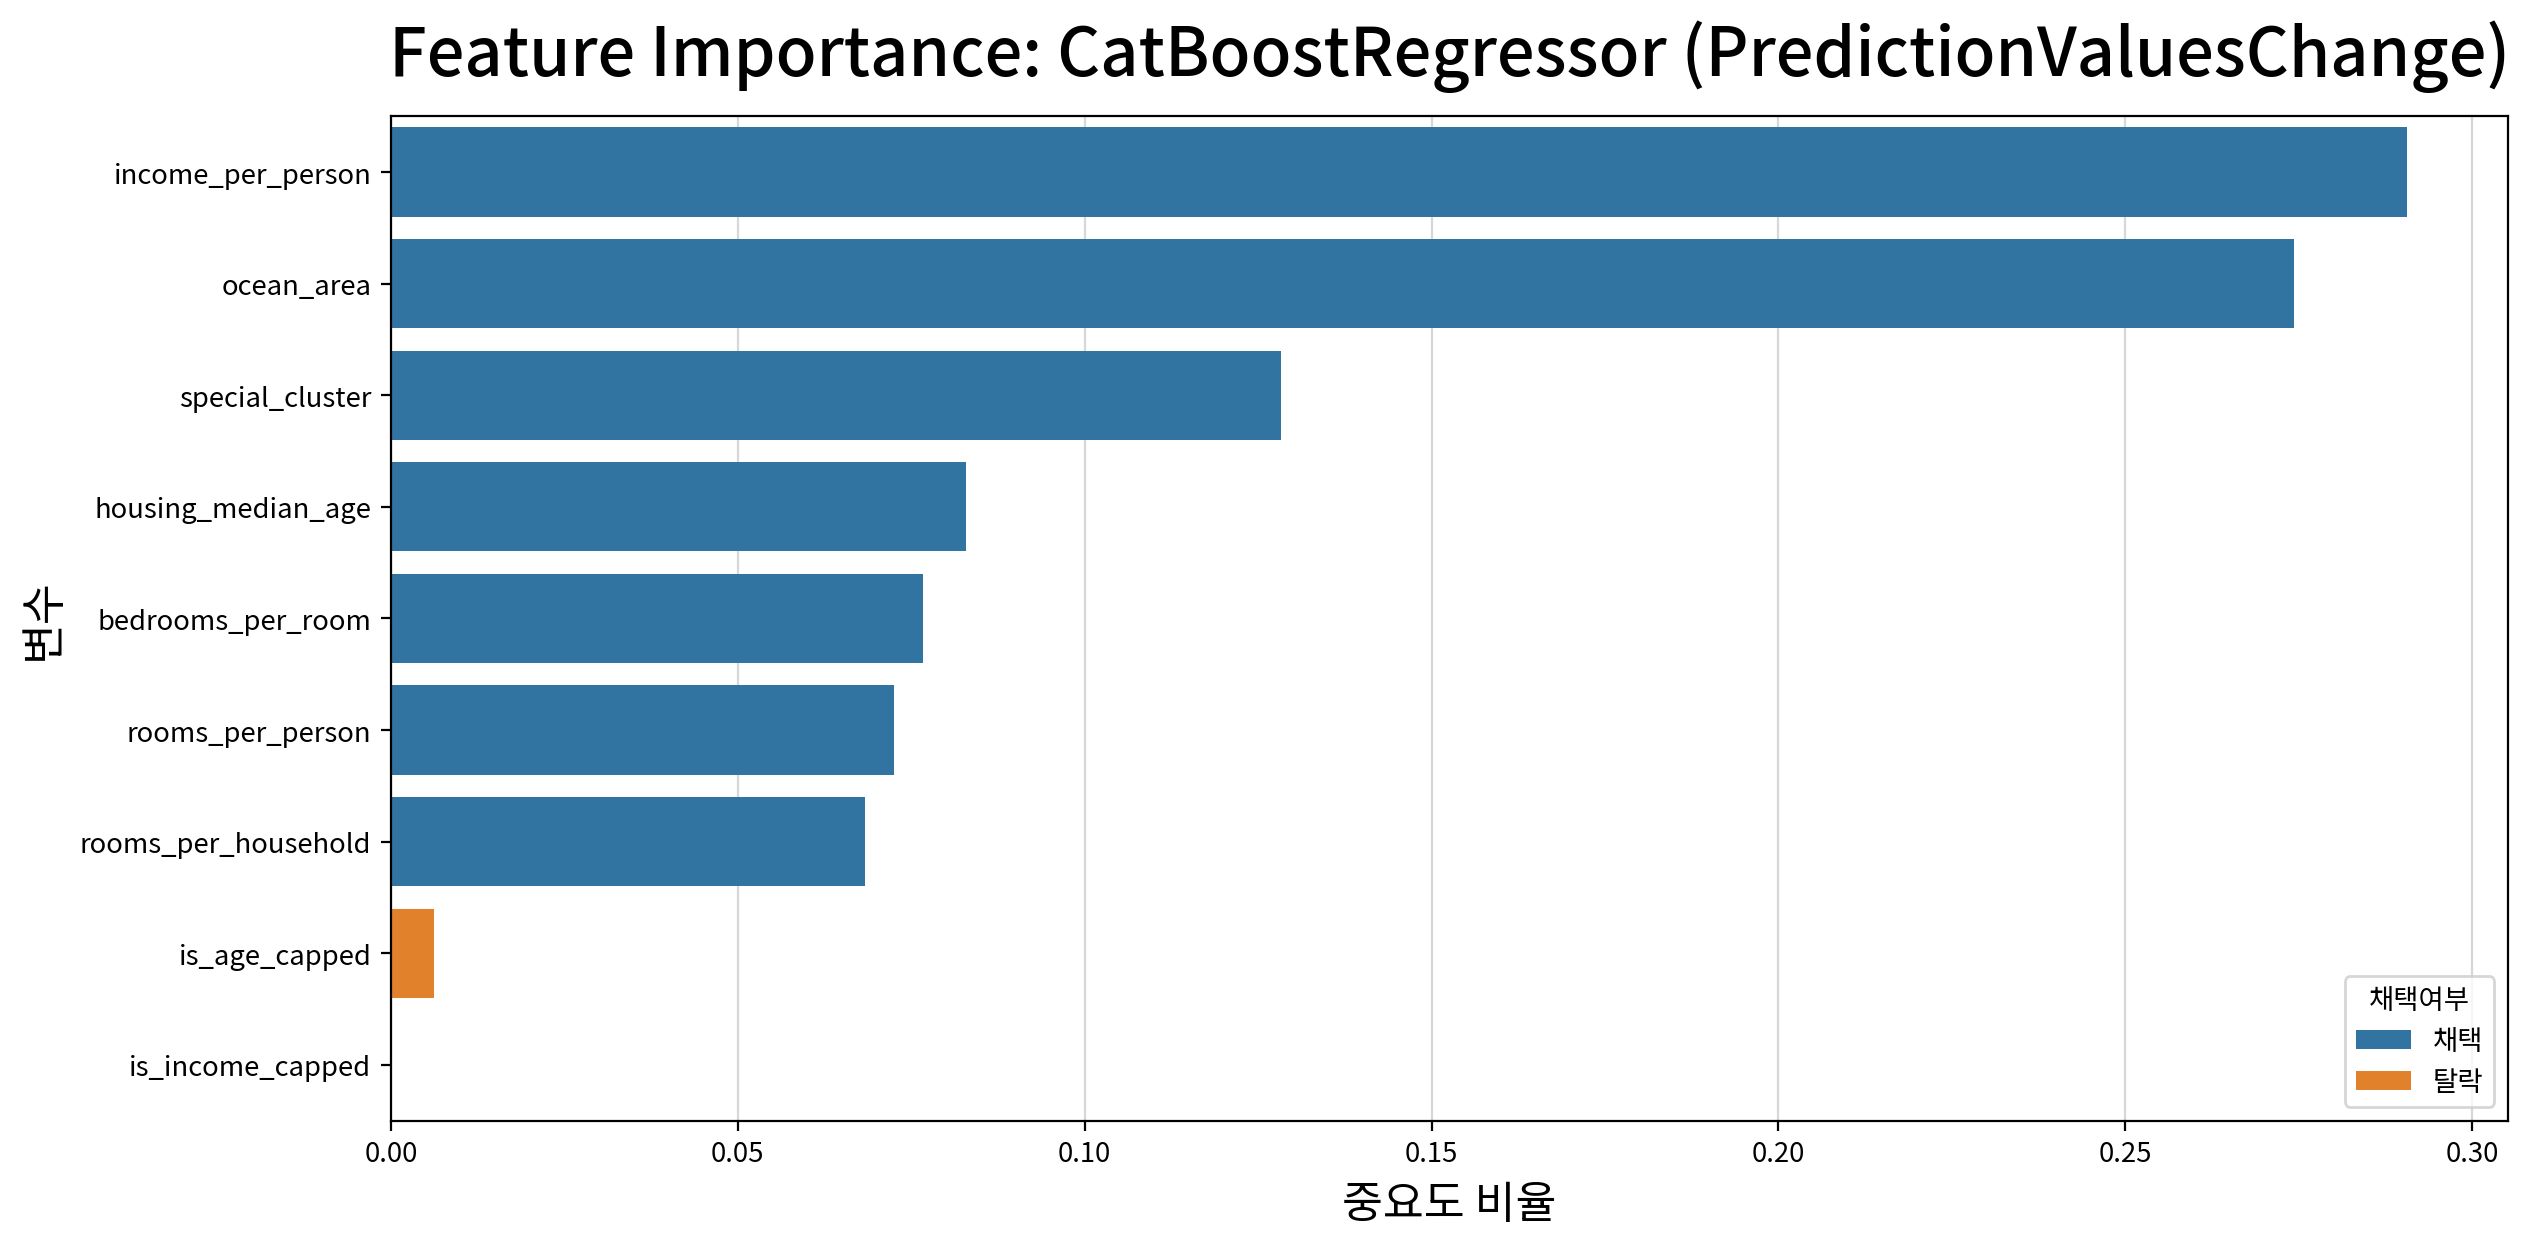


◆ Feature Importance: CatBoostRegressor  (중요도 기준=PredictionValuesChange, 채택 기준=cum_ratio=95%)
   ▷ 탐색 객체의 best_params: {'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.03}
   전체 변수 9개 중 7개 채택 (누적 중요도 99.37% 설명)
   ▶ 채택된 변수: ['income_per_person', 'ocean_area', 'special_cluster', 'housing_median_age', 'bedrooms_per_room', 'rooms_per_person', 'rooms_per_household']



,Importance,Ratio,CumRatio,채택여부
Feature,,,,
income_per_person,29.062,0.291,0.291,채택
ocean_area,27.427,0.274,0.565,채택
special_cluster,12.824,0.128,0.693,채택
housing_median_age,8.289,0.083,0.776,채택
bedrooms_per_room,7.676,0.077,0.853,채택
rooms_per_person,7.250,0.073,0.925,채택
rooms_per_household,6.840,0.068,0.994,채택
is_age_capped,0.617,0.006,1.000,탈락
is_income_capped,0.014,0.000,1.000,탈락


In [8]:
model = my_ml.load_model(f"{workdir}/catboost.pkl")
fi = my_ml.feature_importance(model, cum_ratio=0.95)
fi

### 2. 채택된 변수 추출

- `feature_importance()` 의 반환 표에서 채택/탈락을 확인하고    
   **채택된 변수 목록만** 꺼내 재학습에 사용한다.

In [9]:
# 채택된 변수 목록 (재학습에 사용)
selected = fi.attrs['selected_features']
dropped = [c for c in x_train.columns if c not in selected]

print(f"채택 {len(selected)}개: {selected}")
print(f"탈락 {len(dropped)}개: {dropped}")

채택 7개: ['income_per_person', 'ocean_area', 'special_cluster', 'housing_median_age', 'bedrooms_per_room', 'rooms_per_person', 'rooms_per_household']
탈락 3개: ['population_per_household', 'is_age_capped', 'is_income_capped']


### 3. 데이터에서 채택된 변수만 추출

In [10]:
# 훈련 데이터에서 채택된 변수만 추출
x_tr = x_train[selected]
display(x_tr.columns)

# 검증 데이터에서 채택된 변수만 추출
x_te = x_test[selected]
display(x_te.columns)

Index(['income_per_person', 'ocean_area', 'special_cluster',
       'housing_median_age', 'bedrooms_per_room', 'rooms_per_person',
       'rooms_per_household'],
      dtype='object')

Index(['income_per_person', 'ocean_area', 'special_cluster',
       'housing_median_age', 'bedrooms_per_room', 'rooms_per_person',
       'rooms_per_household'],
      dtype='object')

### 4. 베이스모델 재학습

In [11]:
catboost = my_ml.fit_pipeline(
            model=CatBoostRegressor(
                    random_state=RANDOM_STATE, verbose=0),
            x_train=x_tr, y_train=y_train,
            vif=True, 
            encode=False,   # CatBoost는 자체적으로 범주형 처리하므로 encode=False
            # 이름이 `단계명__인자명` 형식인 인자는 모델의 fit 으로 그대로 전달된다
            model__cat_features=my_qtcheck.get_categorical_column_names(x_tr))

display(my_ml.reg_score(catboost, x_te, y_test))

catboost


대상: 16346행 x 7열 | 모델: catboost
명목형: ['ocean_area', 'special_cluster']
연속형: ['income_per_person', 'housing_median_age', 'bedrooms_per_room', 'rooms_per_person', 'rooms_per_household']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: (변환 없음)

모델 학습 완료: catboost


,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
CatBoostRegressor,0.782,0.195,0.072,0.268,0.021,0.016,-0.000


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

### 5. 하이퍼파라미터 튜닝

In [12]:
# 수업용 탐색 조합
param_grid = {
    "model__iterations": [500, 1000],
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.03, 0.05, 0.1]
}

# 하이퍼파라미터 튜닝 수행
gs = GridSearchCV(estimator=catboost, param_grid=param_grid,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

gs.fit(x_tr, y_train,
       model__cat_features=my_qtcheck.get_categorical_column_names(x_tr))

gs.name_ = f"{model.name_}_tuned"   # 튜닝이 완료된 객체에게 모델이름을 부여한다.
my_ml.save_model(gs, f"{savedir}/catboost.pkl") # 튜닝이 완료된 모델을 저장한다.
display(my_ml.reg_score(gs, x_te, y_test))      # 성능 평가

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
CatBoostRegressor,0.785,0.194,0.071,0.266,0.020,0.016,-0.000


### 6. 과적합 판정

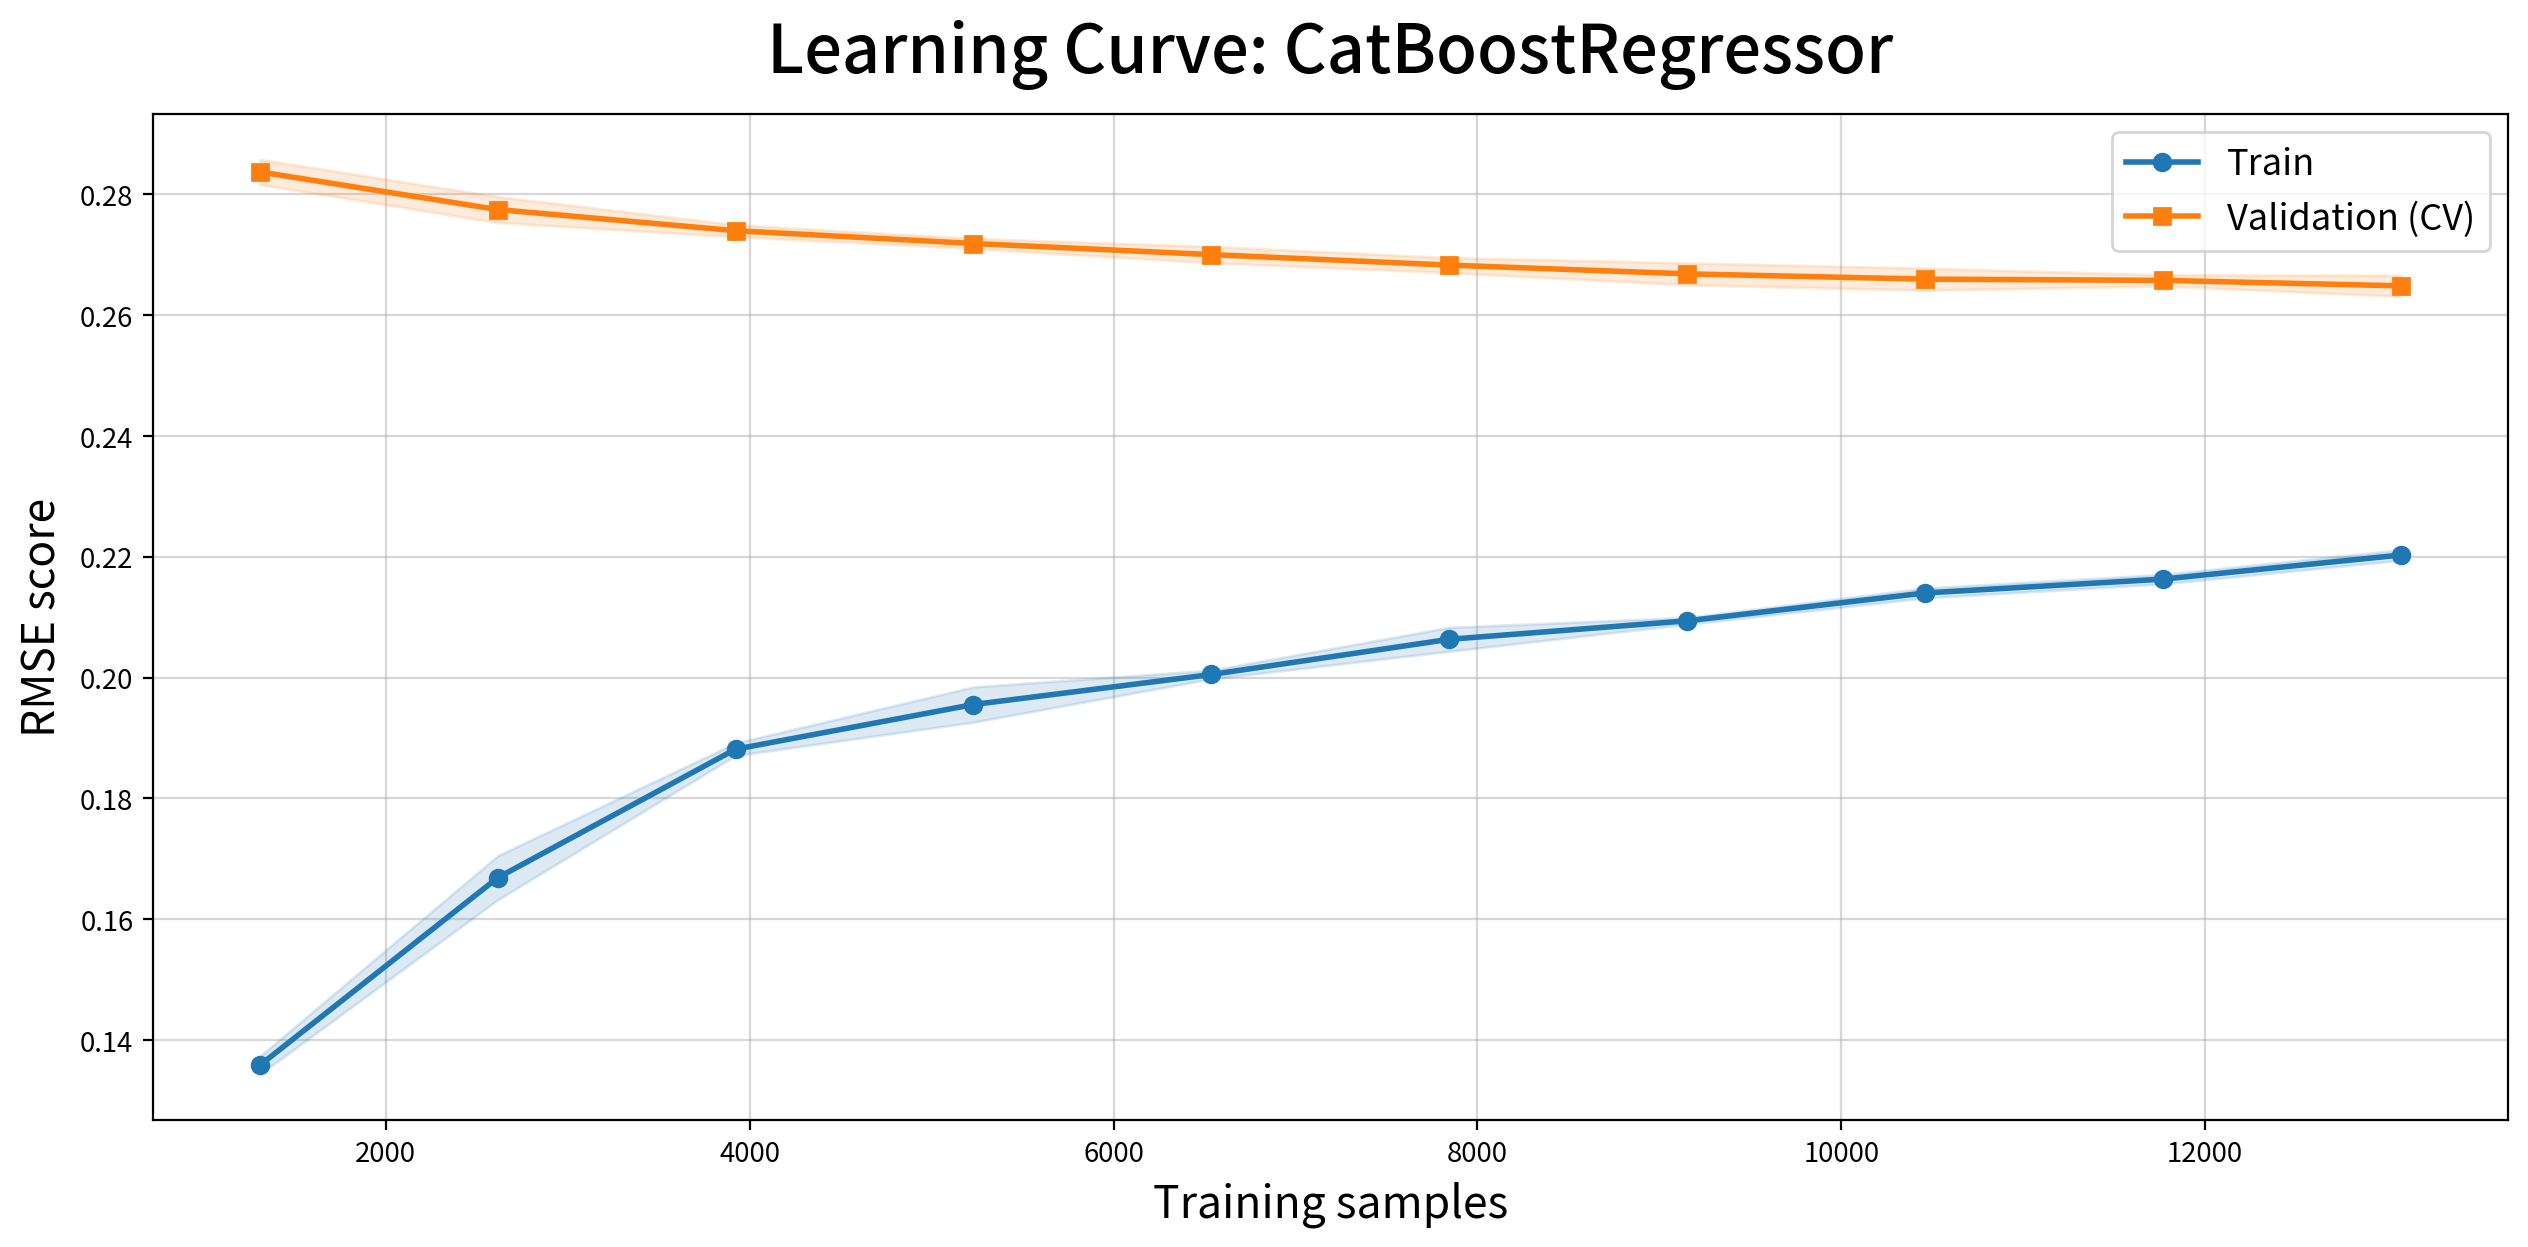


◆ Fit Diagnosis: CatBoostRegressor  (threshold=15%, 기준=Train↔CV 5-Fold)
   ▷ 탐색 객체의 best_params: {'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.03}
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
   - RMSE    Train=     0.2236  CV=     0.2651 (±0.0016)  Test=     0.2659  Gap%=   15.66%  [과대적합] ⚠

   ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) — 훈련↔CV 격차가 큼
     · train R2=0.8451 (과소적합 기준 < 0.3) · CV R2=0.7822

CPU times: total: 3.81 s
Wall time: 10min 39s


,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.224,0.265,0.002,0.266,0.042,15.660,과대적합


In [13]:
%%time
my_ml.reg_overfit(gs, x_tr, y_train, x_te, y_test, metrics="RMSE", 
    fit_params={'model__cat_features': my_qtcheck.get_categorical_column_names(x_tr)})

## #04 SHAP 분석

### 1. SHAP Explainer 객체 생성

- 모듈 내부에서 모델 유형에 맞는 Explainer가 생성된다.
- 두 종류의 Summary Plot이 시각화 된다 (Bar Plot과 Beeswarm)

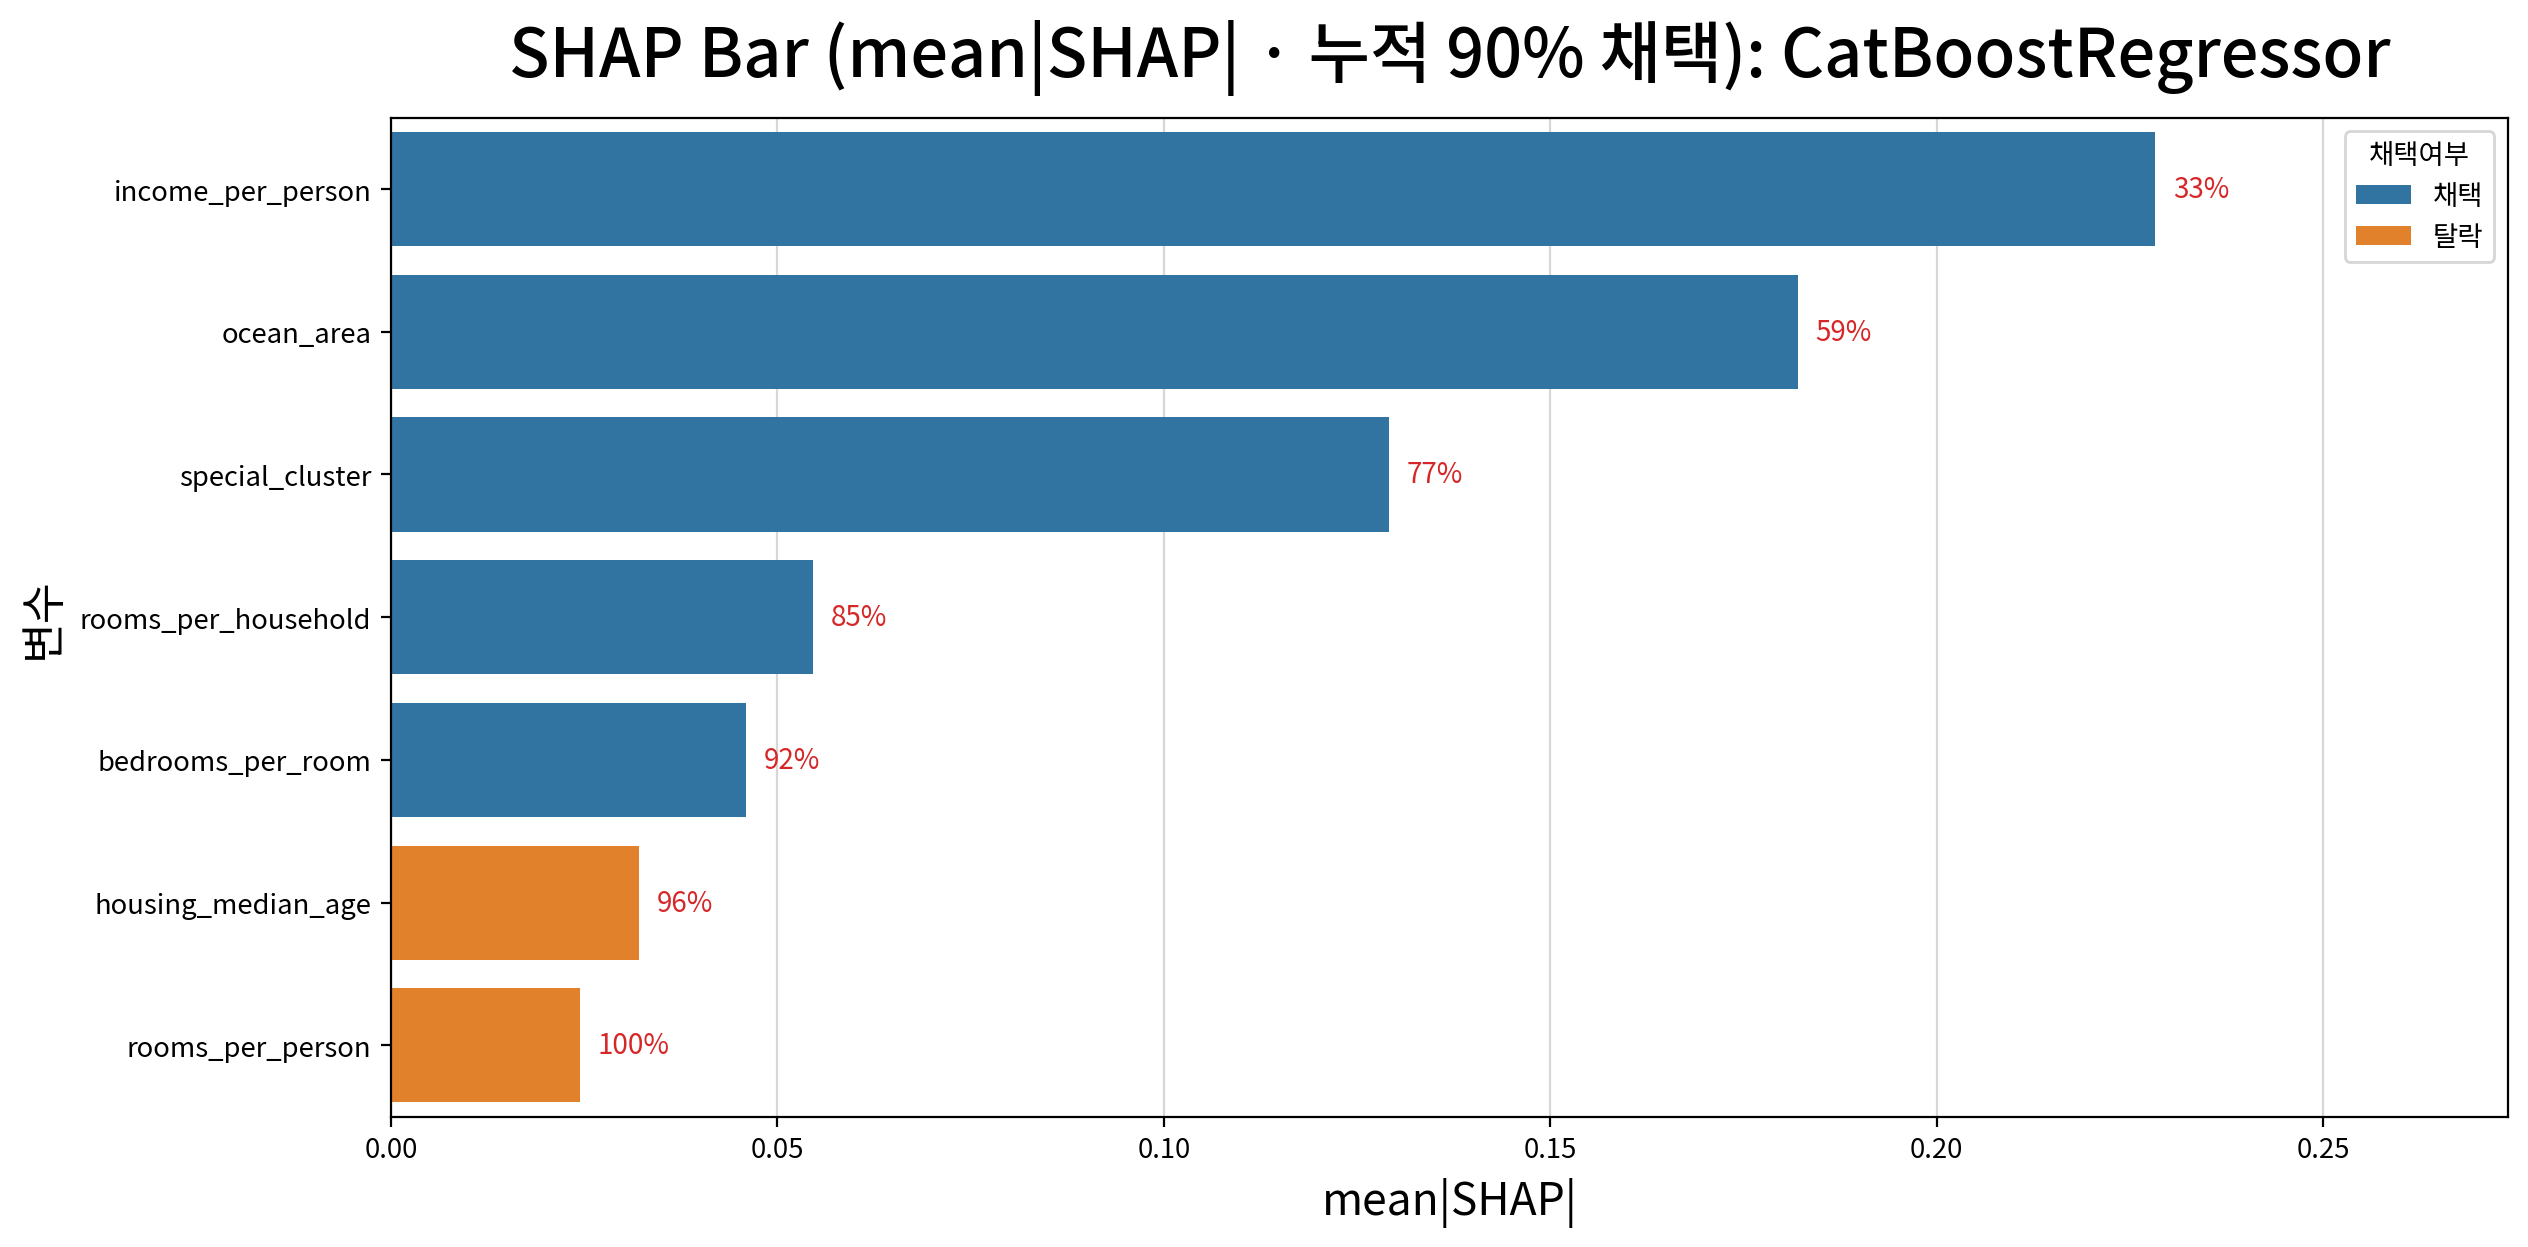

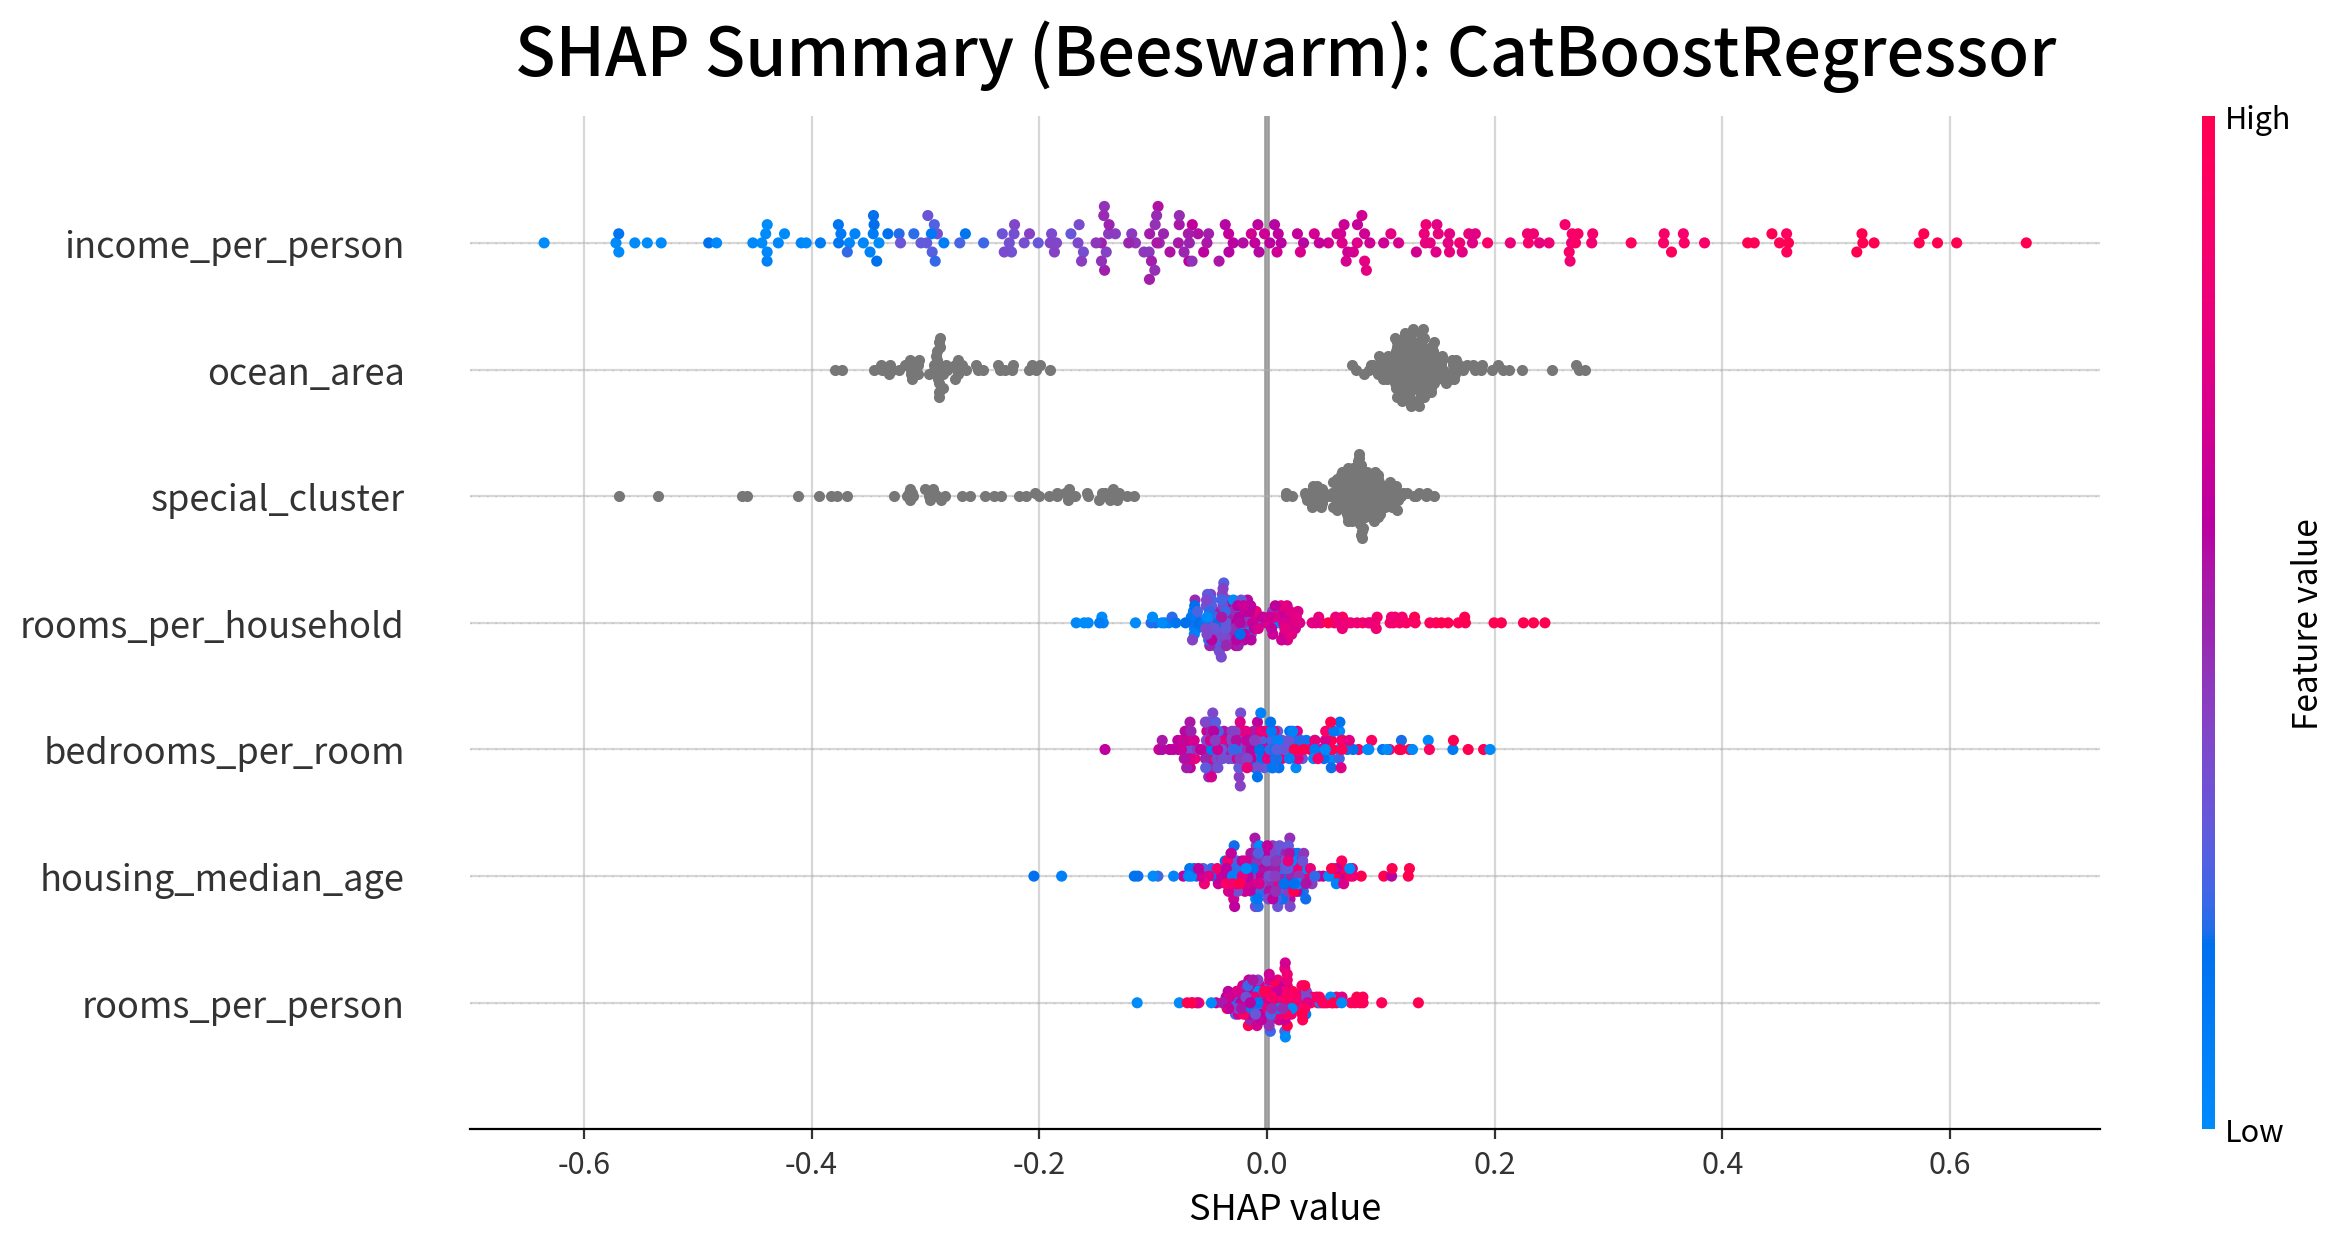


◆ SHAP Analysis: CatBoostRegressor  (TreeExplainer, regression)
   ▷ 탐색 객체의 best_params: {'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.03}
   설명 표본 200행 × 변수 7개 · base value=12.0859 · SHAP 단위=예측값(y 단위)
   income_per_person      mean|SHAP|=0.2283  방향=감소  비선형/불안정
   ocean_area             mean|SHAP|=0.1820  방향=증가  비선형/불안정
   special_cluster        mean|SHAP|=0.1292  방향=감소  비선형/불안정
   rooms_per_household    mean|SHAP|=0.0547  방향=감소  비선형/불안정
   bedrooms_per_room      mean|SHAP|=0.0460  방향=증가  비선형/불안정



In [14]:
# 앞에서 학습 완료한 최종 모델과 데이터 사용
shap = my_ml.shap_analysis(gs, x_tr)

#### SHAP 요약 — 현재 실행 결과

- 설명 표본은 200행이며 최종 입력 변수는 7개이다.
- mean|SHAP| 상위 변수는 `income_per_person`(0.2283), `ocean_area`(0.1820), `special_cluster`(0.1292), `rooms_per_household`(0.0547), `bedrooms_per_room`(0.0460) 순이다.
- Feature Importance 단계에서 선택된 변수에는 `rooms_per_person`이 포함되고 `population_per_household`는 제외되었다. 이전 실행의 변수 목록과 혼동하지 않는다.
- 소득 대리변수와 입지 변수가 이 모델의 예측 설명에서 상위권에 있다. 이는 인과효과나 특정 비율의 가격 결정력을 뜻하지 않는다.
- SHAP은 로그 예측값 단위이다. 평균 절대 SHAP을 단순히 지수화하여 대칭적인 가격 상승·하락률로 해석하지 않는다.
- 콘솔의 방향 요약만으로 변수의 증가·감소 효과를 단정하지 않고 Beeswarm과 Dependence Plot을 함께 확인한다.
- Feature Importance와 SHAP은 서로 다른 중요도 지표이며, 순위 일치가 독립적인 교차검증이나 변수 제거의 안전성을 보장하지 않는다.


### 2. Dependence Plot

◆ SHAP Dependence — 변수쌍(주변수 × 상호작용변수) · 선정기준=cum_ratio=90%
   income_per_person  ×  rooms_per_household
   ocean_area  ×  special_cluster
   special_cluster  ×  income_per_person
   rooms_per_household  ×  bedrooms_per_room
   bedrooms_per_room  ×  rooms_per_household


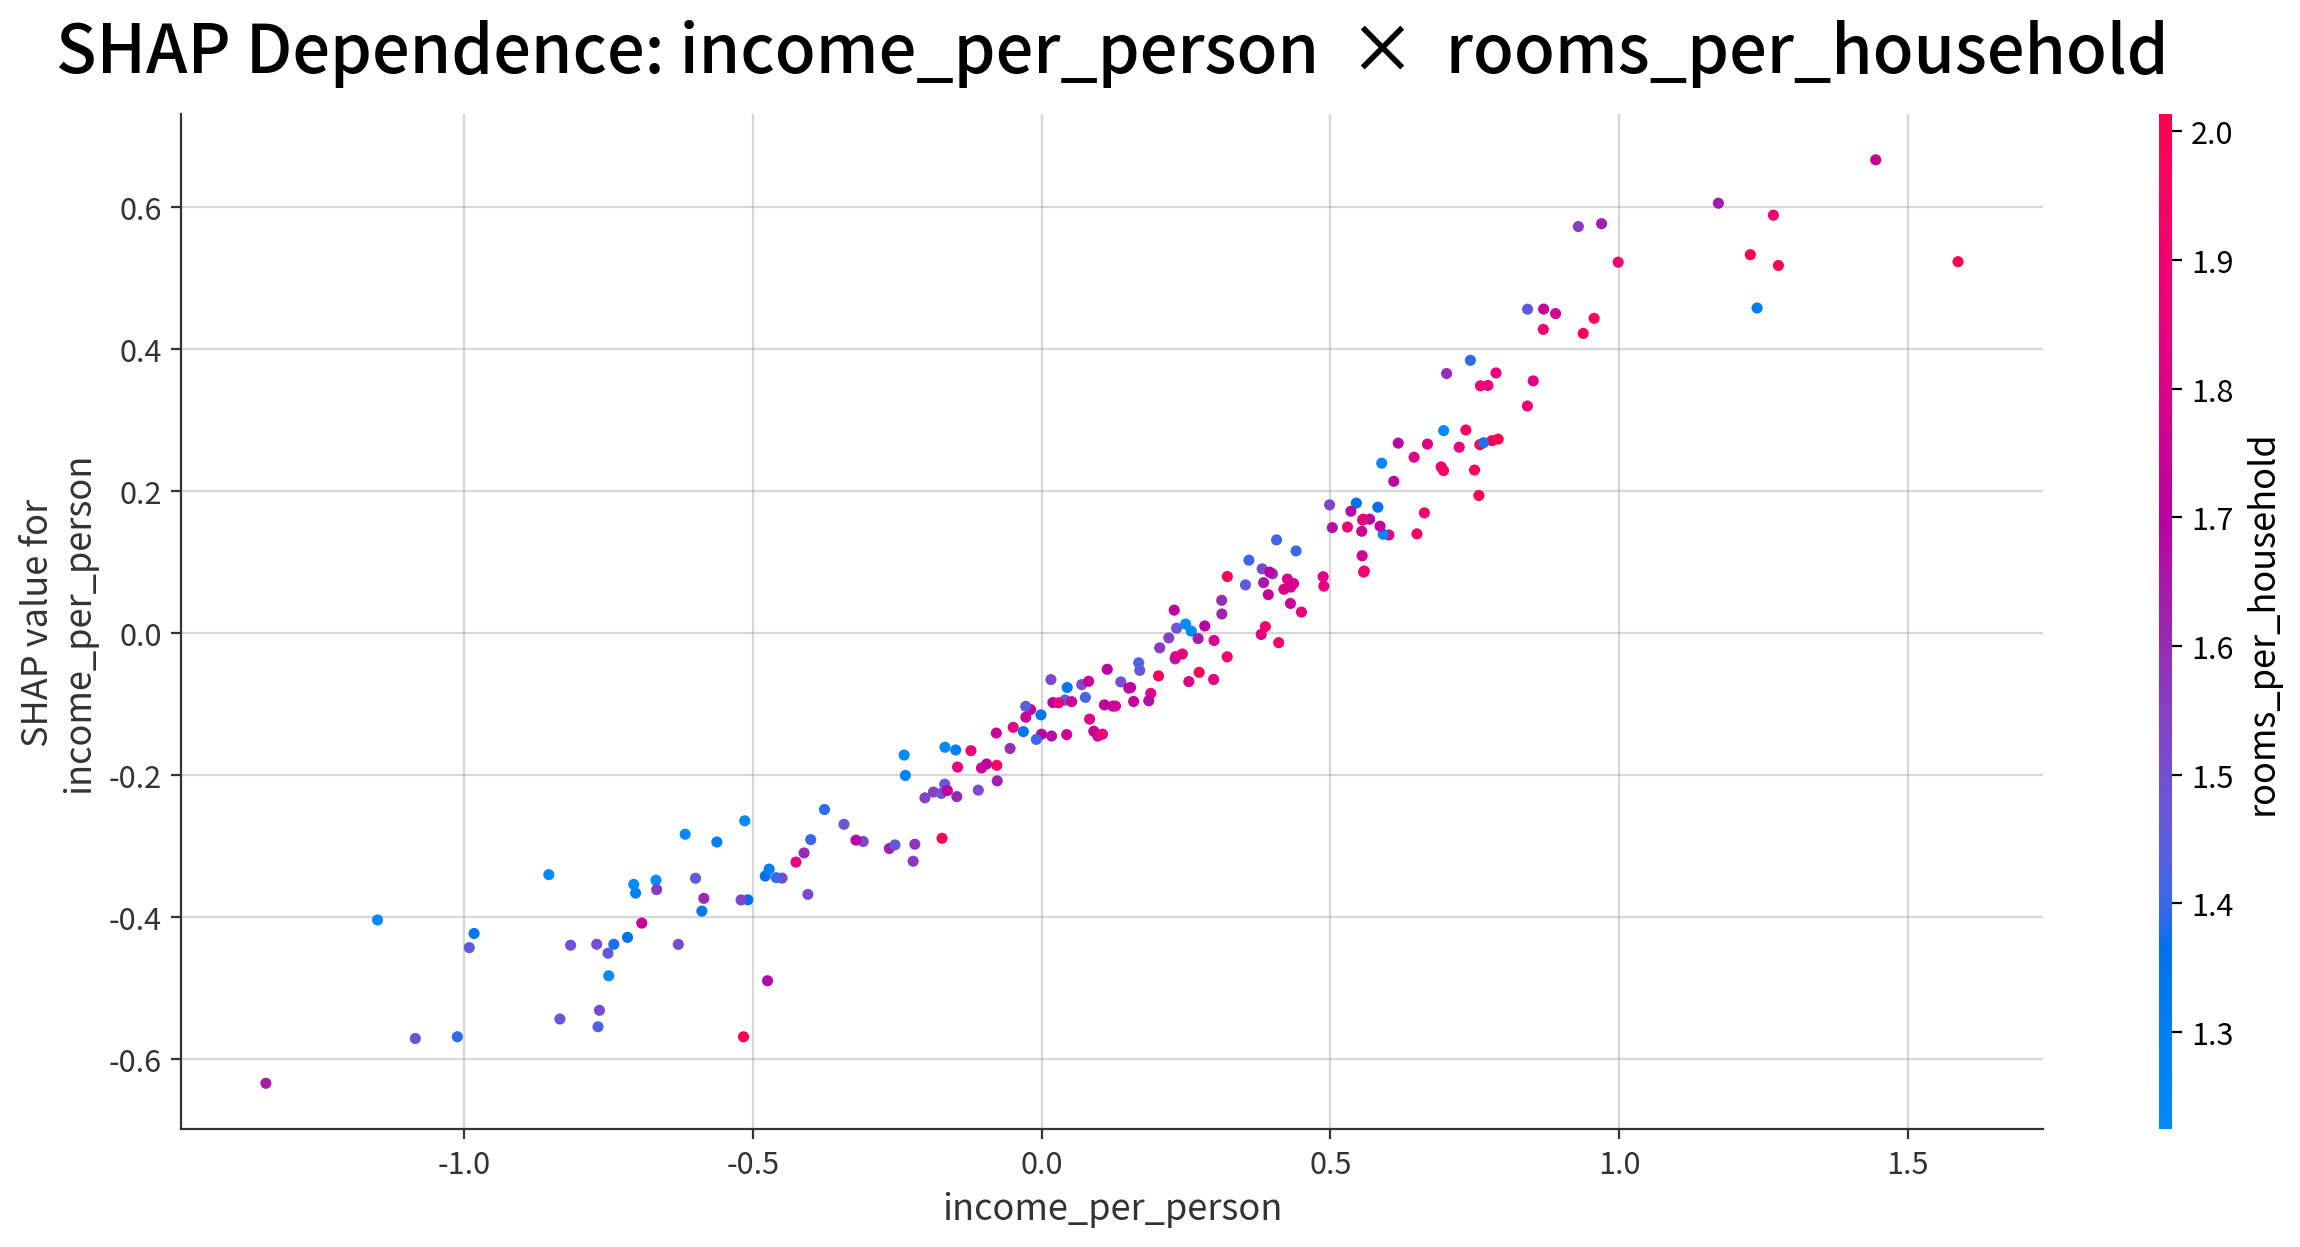

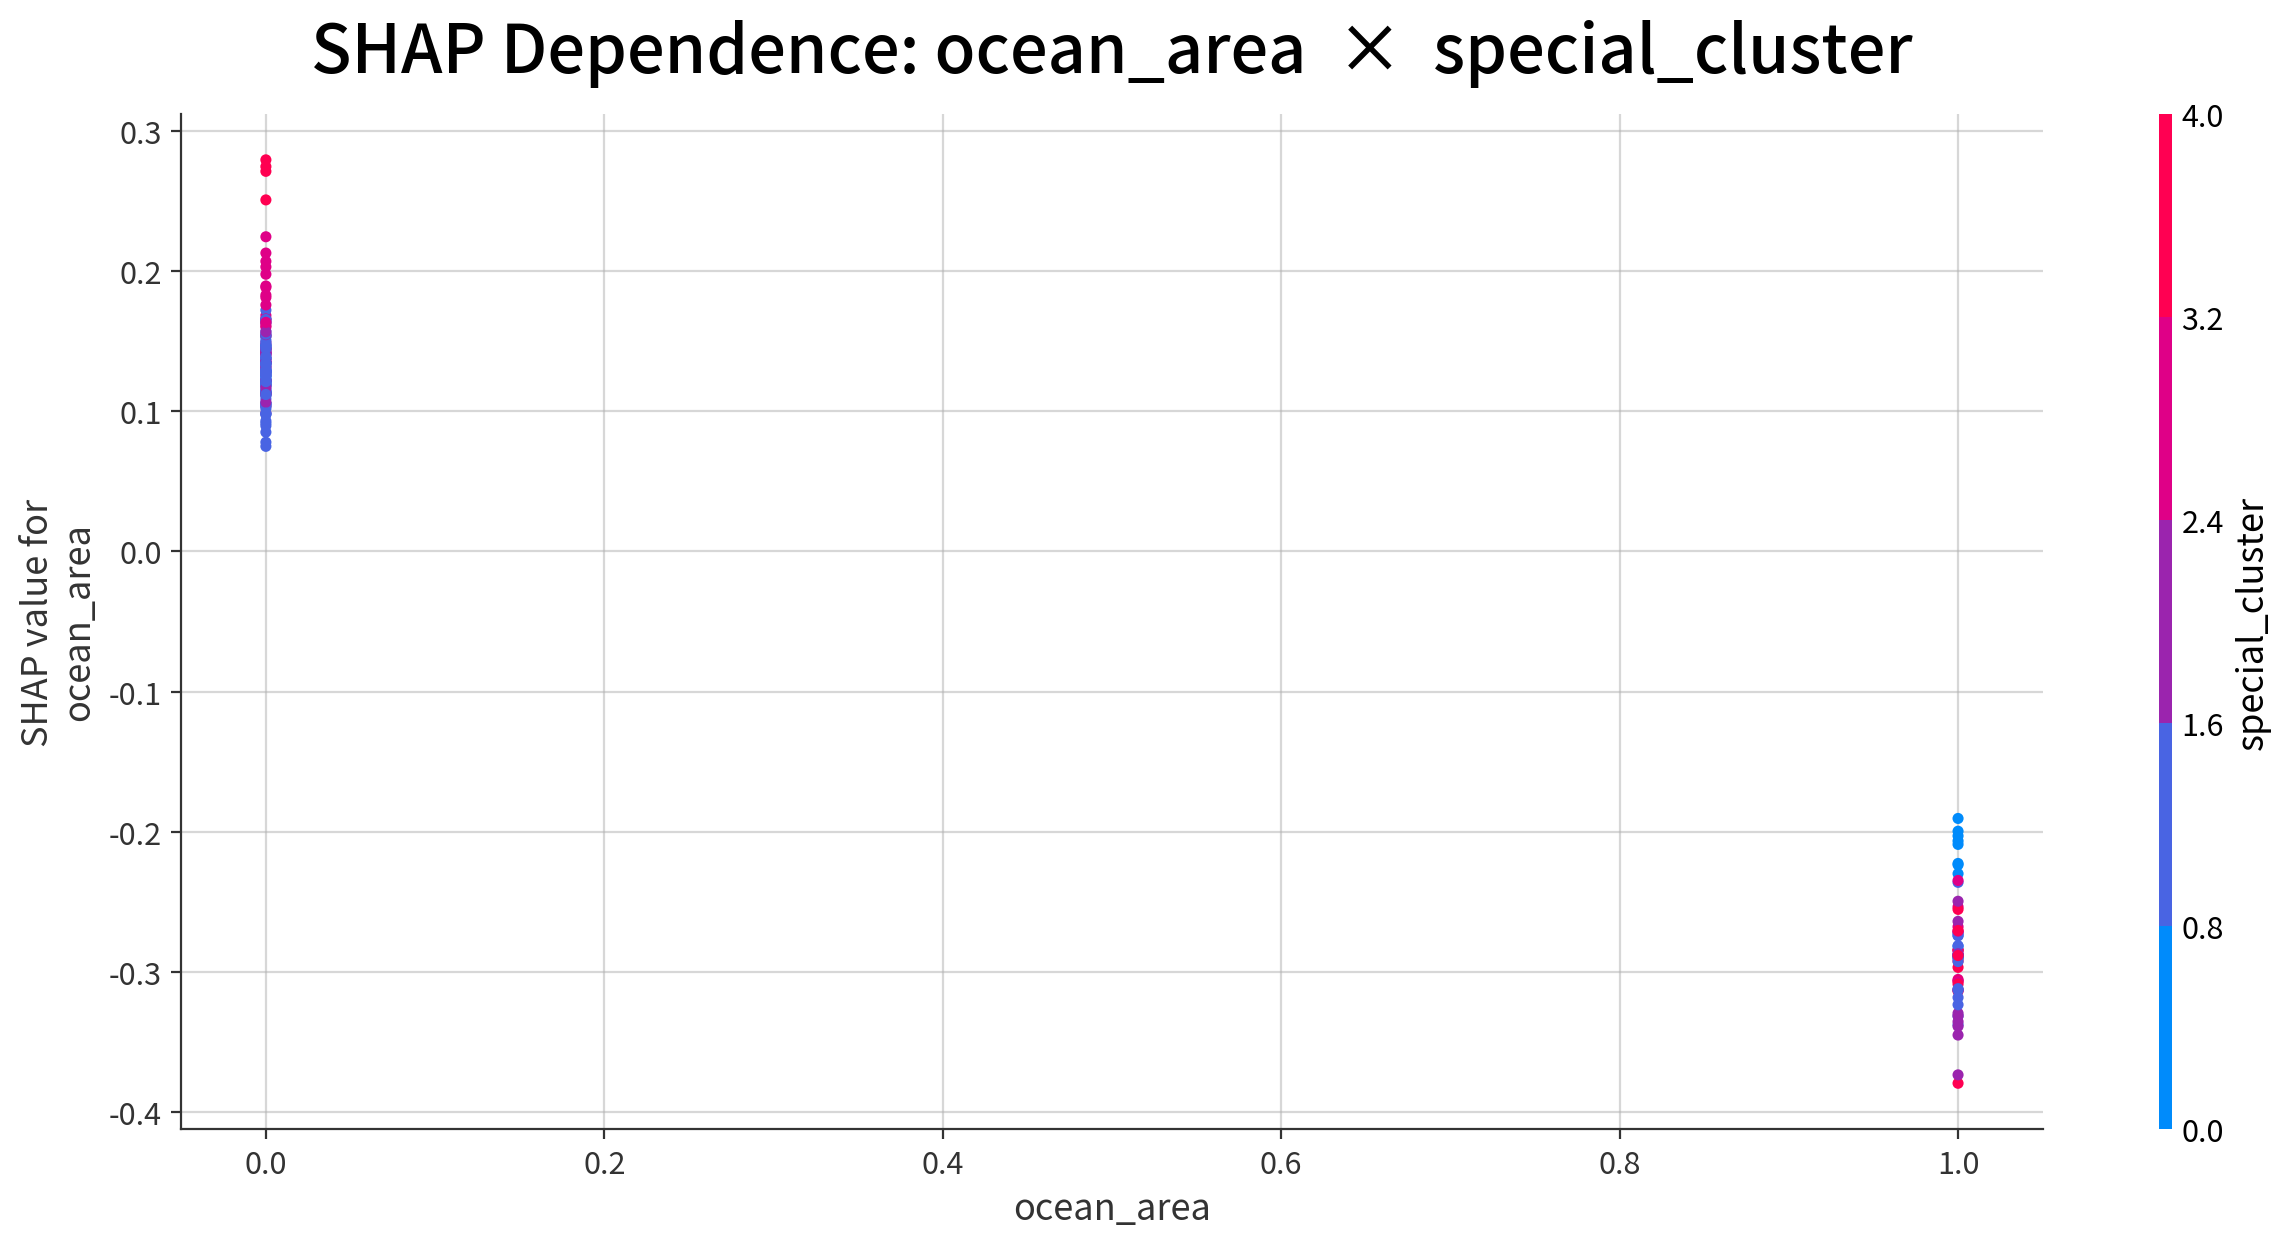

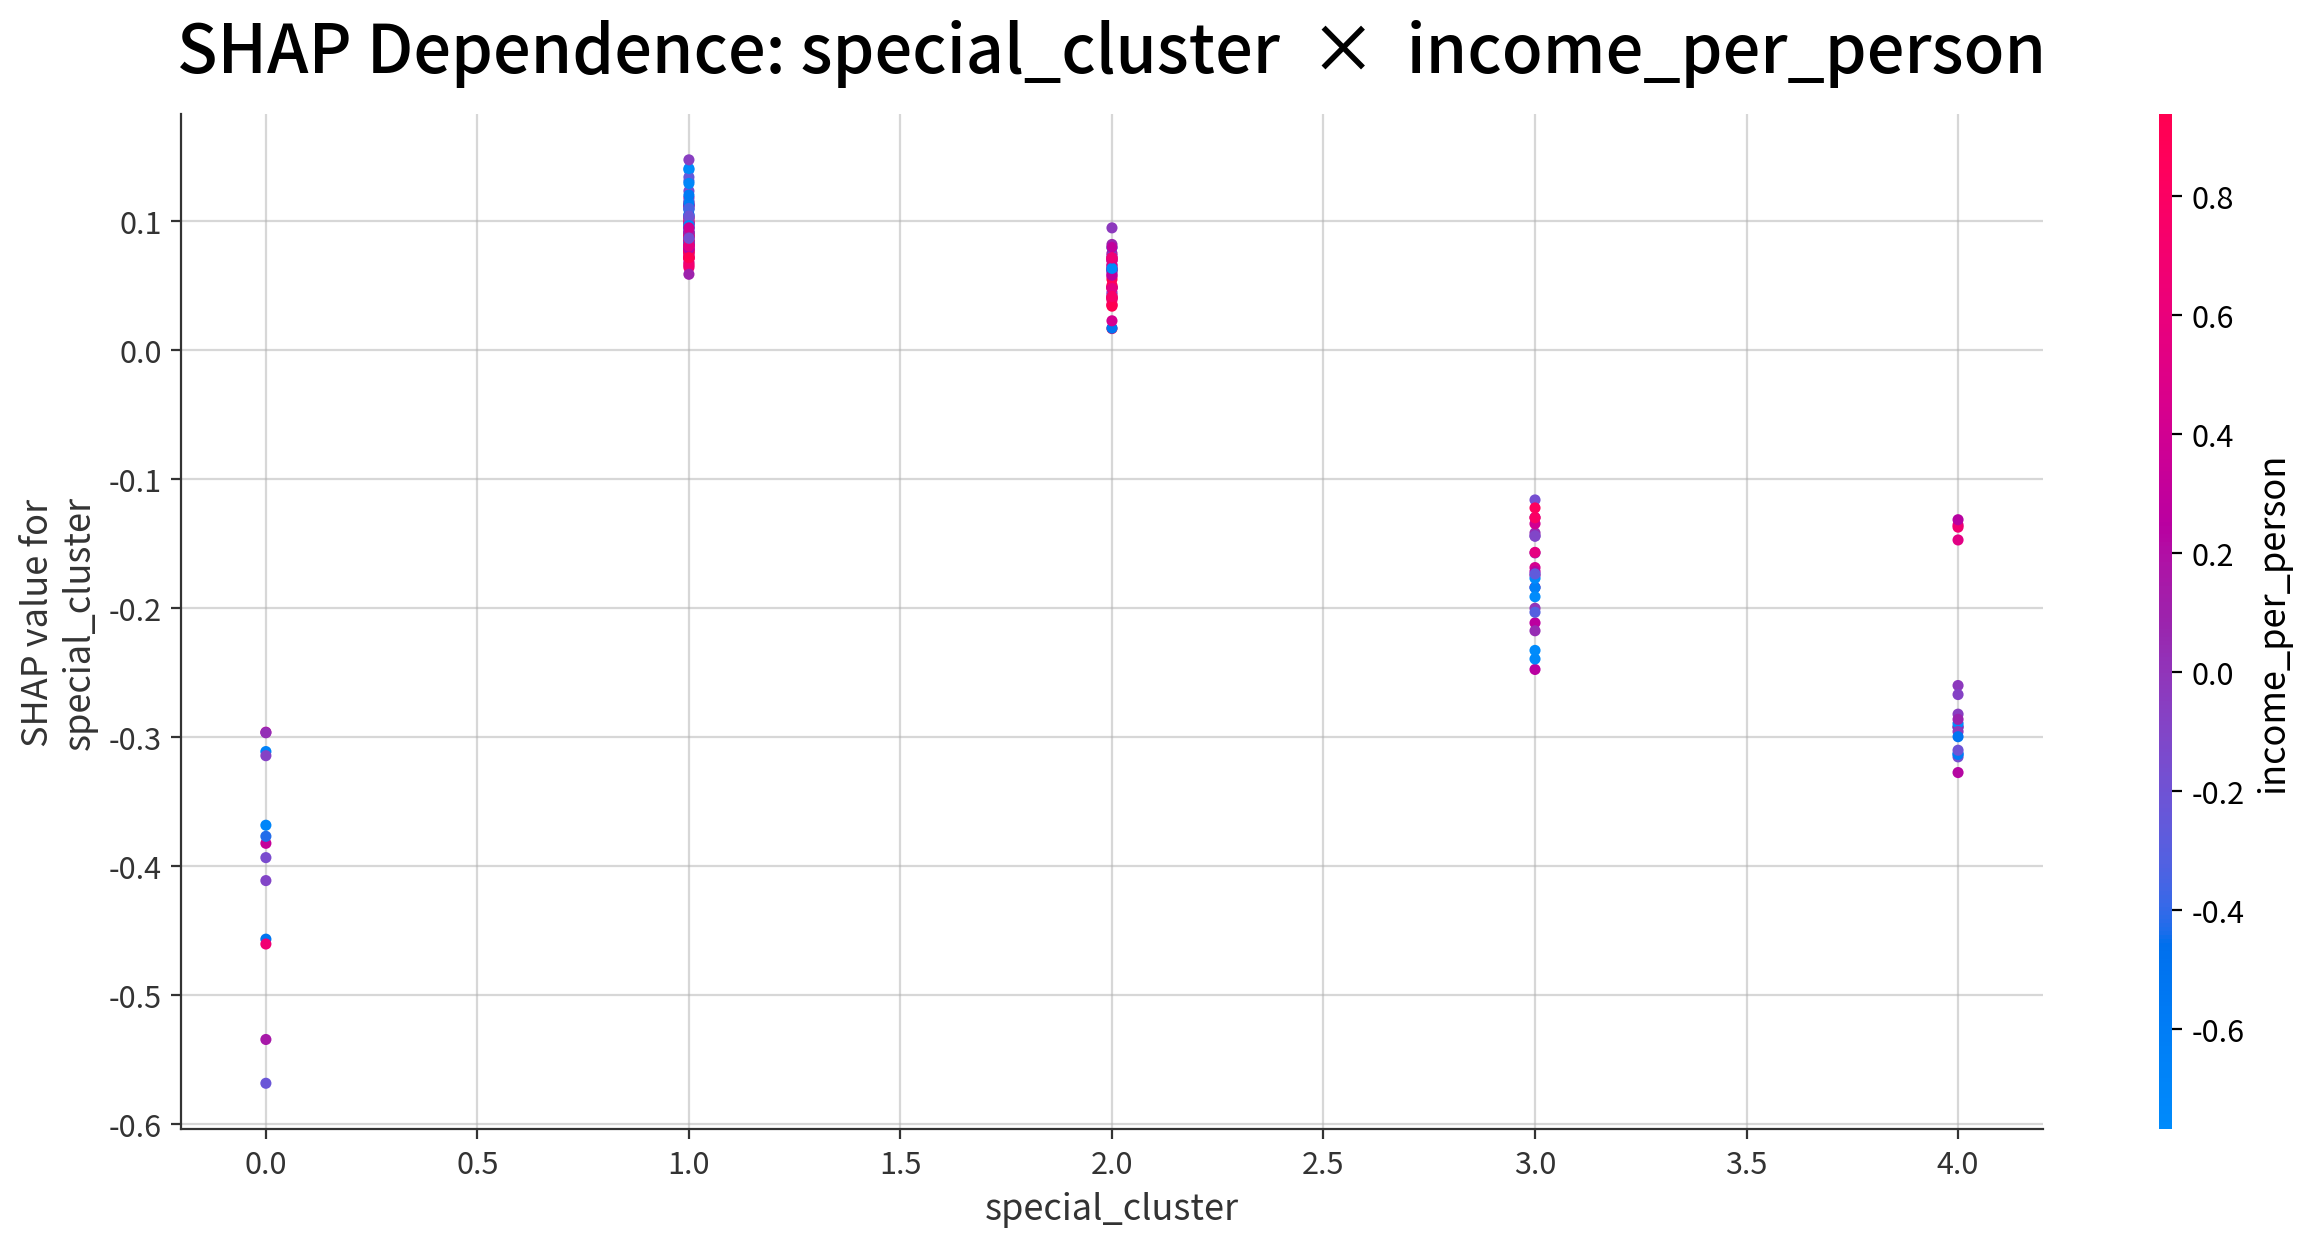

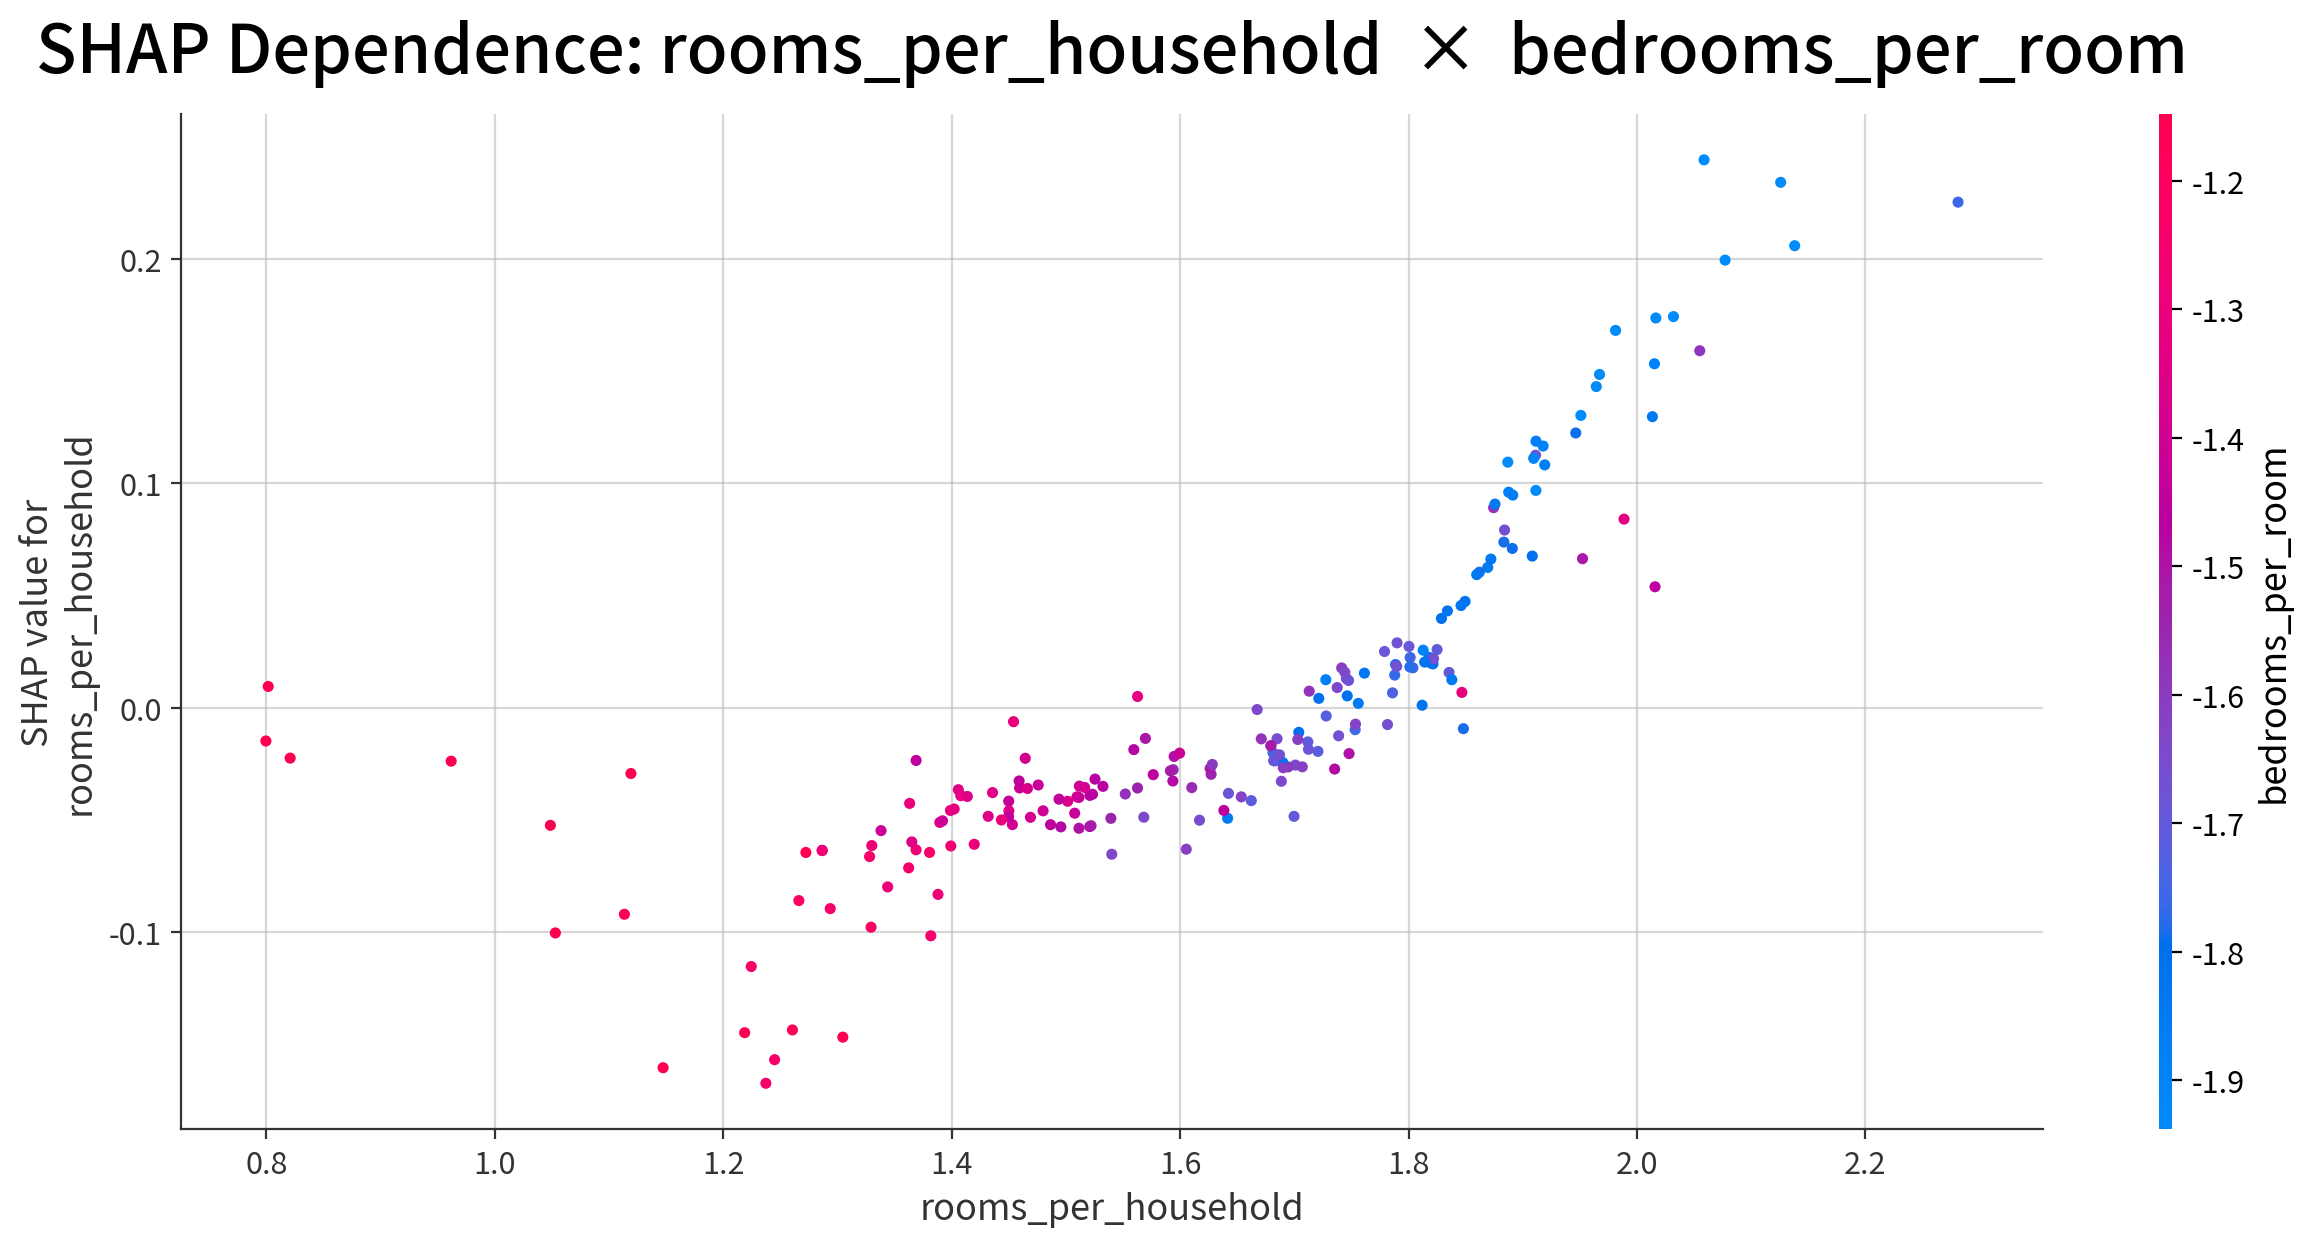

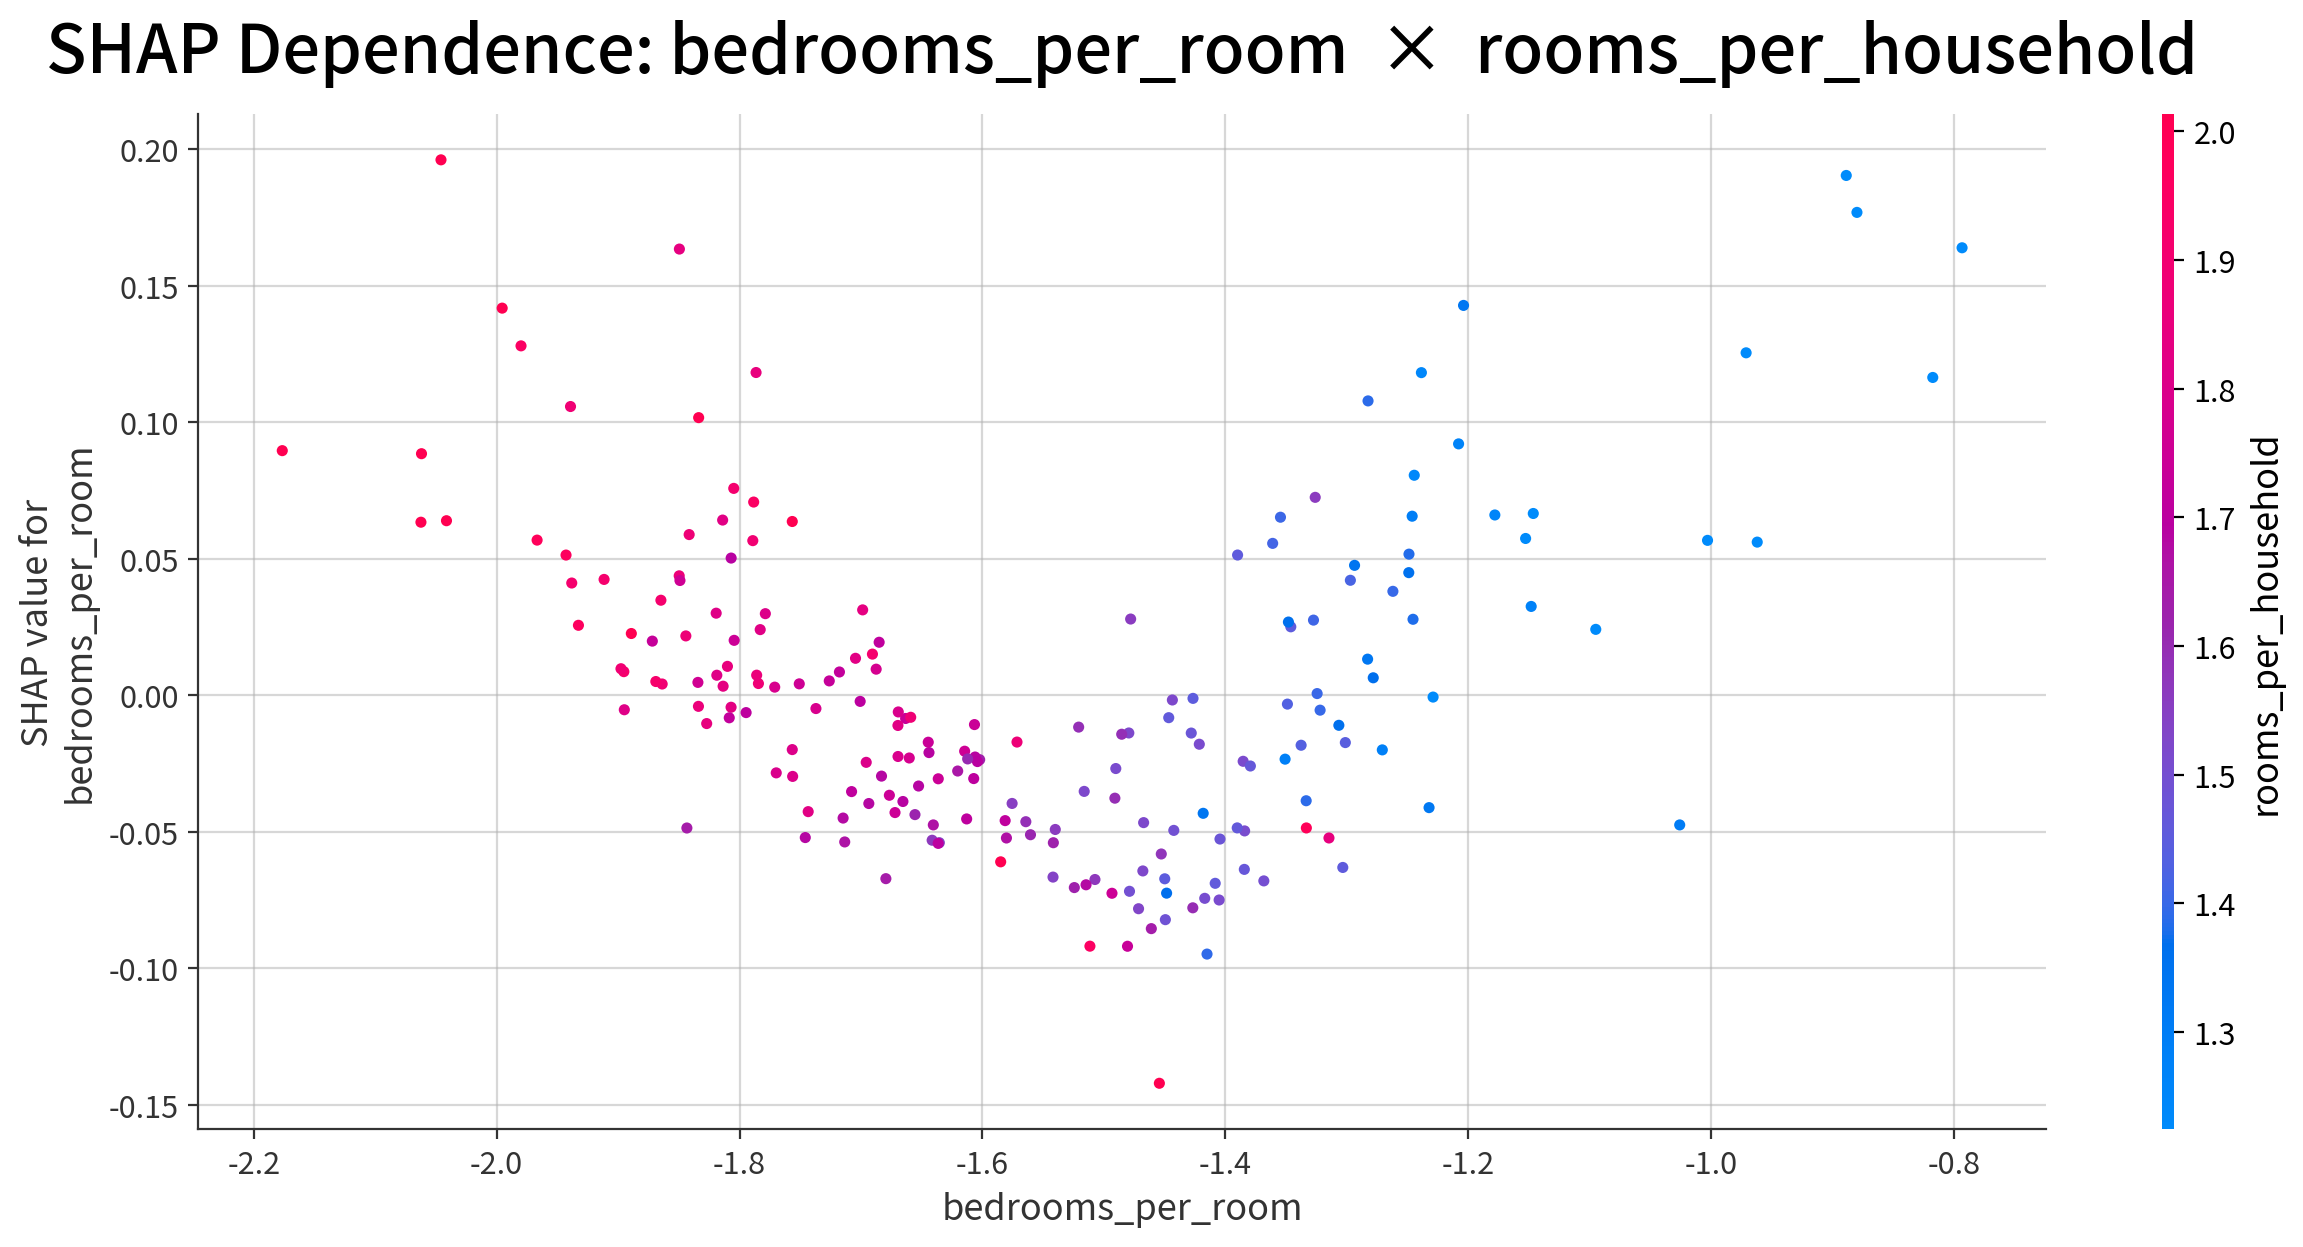

[{'feature': 'income_per_person',
  'interaction_feature': 'rooms_per_household'},
 {'feature': 'ocean_area', 'interaction_feature': 'special_cluster'},
 {'feature': 'special_cluster', 'interaction_feature': 'income_per_person'},
 {'feature': 'rooms_per_household',
  'interaction_feature': 'bedrooms_per_room'},
 {'feature': 'bedrooms_per_room',
  'interaction_feature': 'rooms_per_household'}]

In [15]:
# 데이터는 shap.attrs 에서 읽으므로 훈련데이터를 넘기지 않는다.
# features 를 비워야 cum_ratio/top_k 자동선정이 동작한다.
my_ml.shap_dependence_plot(shap)

#### Dependence Plot — 현재 실행에서 선정된 변수쌍

| 주변수 | 색상으로 표시한 변수 |
|---|---|
| `income_per_person` | `rooms_per_household` |
| `ocean_area` | `special_cluster` |
| `special_cluster` | `income_per_person` |
| `rooms_per_household` | `bedrooms_per_room` |
| `bedrooms_per_room` | `rooms_per_household` |

위 표는 이번 실행의 자동 선정 결과와 일치한다. 각 그래프의 x축은 변수값, y축은 해당 변수의 SHAP 기여도이다. 색상 패턴은 상호작용을 탐색하는 단서이나 그 자체로 상호작용이나 인과관계를 입증하지 않는다. 표본이 적은 구간의 가격 효과나 임계값을 단정하지 않는다.

최종 평가: R² 약 **0.785**, RMSE **0.2659**(로그 척도), 5-Fold CV RMSE **0.2651 ± 0.0016**. 훈련–CV 격차 **15.66%**로 도우미 함수의 15% 경험적 기준에서 과대적합 경고가 남았다. 성능과 이 한계를 함께 보고한다.
